In [10]:
data = torch.load('/localhome/asa420/MIAL/data/confocal-data/ATL/ATL_20frames.pt')
# data[0].shape
data.shape
# dataset = TensorDataset(your_data_reshaped[:-2], your_data[-2:])

torch.Size([130, 20, 1, 128, 128])

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Define an autoencoder model for frame generation
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(19, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        # Decoder
        self.decoder = nn.Sequential(
            # Add inverse operations of the encoder layers
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Sigmoid for pixel values in [0, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Hyperparameters
batch_size = 32
learning_rate = 0.004
num_epochs = 40

# Assuming you have a tensor 'your_data' with sequential frames
# Ensure that your_data has the shape (batch_size, sequence_length, channels, height, width)
# Here, 'sequence_length' is the number of frames in each sequence.

your_data = torch.load('/localhome/asa420/MIAL/data/confocal-data/ATL/ATL_20frames.pt')

# Stack frames along the channel dimension to create a 5-channel input
# your_data_reshaped = your_data.permute(0, 2, 1, 3, 4).contiguous().view(batch_size, -1, your_data.size(3), your_data.size(4))

# your_data_reshaped = your_data
# your_data_reshaped = your_data.permute(0, 2, 1, 3, 4).contiguous().view(batch_size, -1, your_data.size(3), your_data.size(4))

inputs = your_data[:, :19].reshape(-1, 19, 128, 128)
targets = your_data[:, 19:].reshape(-1, 1, 128, 128)

# plt.imshow(inputs[0][2])
# plt.imshow(targets[0][1])



In [28]:

# Create a DataLoader with your reshaped dataset
dataset = TensorDataset(inputs, targets)  # Assuming you want to predict the next frame
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


# Create a DataLoader with your reshaped dataset
# dataset = TensorDataset(your_data_reshaped[:-2], your_data[-2:])
# dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model, loss function, and optimizer
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    for batch in dataloader:
        inputs, targets = batch
        inputs, targets = inputs.float(), targets.float()
        # print(inputs.shape)
        # print(targets)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')

# print(outputs.shape)

Epoch [1/40], Loss: 2195.573974609375
Epoch [2/40], Loss: 2178.940673828125
Epoch [3/40], Loss: 2167.73974609375
Epoch [4/40], Loss: 2167.50830078125
Epoch [5/40], Loss: 2167.529296875
Epoch [6/40], Loss: 2167.55126953125
Epoch [7/40], Loss: 2167.57177734375
Epoch [8/40], Loss: 2167.58935546875
Epoch [9/40], Loss: 2167.602783203125
Epoch [10/40], Loss: 2167.61181640625
Epoch [11/40], Loss: 2167.616943359375
Epoch [12/40], Loss: 2167.618408203125
Epoch [13/40], Loss: 2167.616455078125
Epoch [14/40], Loss: 2167.611572265625
Epoch [15/40], Loss: 2167.60400390625
Epoch [16/40], Loss: 2167.59375
Epoch [17/40], Loss: 2167.581298828125
Epoch [18/40], Loss: 2167.56787109375
Epoch [19/40], Loss: 2167.554443359375
Epoch [20/40], Loss: 2167.5439453125
Epoch [21/40], Loss: 2167.537109375
Epoch [22/40], Loss: 2167.533203125
Epoch [23/40], Loss: 2167.53076171875
Epoch [24/40], Loss: 2167.528564453125
Epoch [25/40], Loss: 2167.52685546875
Epoch [26/40], Loss: 2167.524658203125
Epoch [27/40], Loss: 21

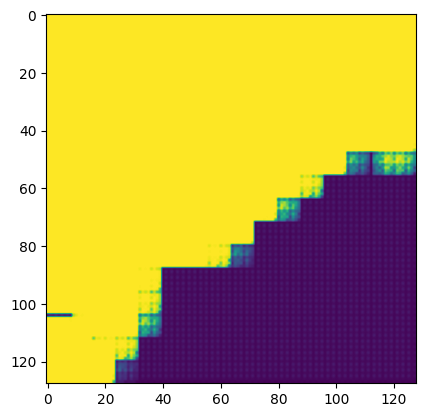

In [30]:
plt.imshow(outputs.detach().numpy()[0][0])

In [17]:
import imageio
import numpy as np
import torch

def load_data(group):
    data_path = f'/localhome/asa420/MIAL/data/confocal-data/{group}/er_mean/'

    group_num = {'ATL': 26, 'Climp': 31, 'Control': 31, 'Reticulon': 29}

    data = []
    for num in range(1, group_num[group]+1):
        file = imageio.imread(data_path + f'{group.lower()}{num}_er_mean.png')
        file = np.expand_dims(file, axis=0)
        data.append(file)

    data = np.stack(data, axis=0)
    data = torch.from_numpy(data)
    return data

In [18]:
atl_data = load_data('ATL')

print(type(atl_data))
print(type(atl_data[0]))
print(type(atl_data[0][0]))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


/tmp/ipykernel_2534775/1048547781.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  file = imageio.imread(data_path + f'{group.lower()}{num}_er_mean.png')


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torch.autograd import Variable

# Define the VAE architecture
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2_mean = nn.Linear(hidden_dim, latent_dim)
        self.fc2_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        x = F.relu(self.fc1(x))
        mean = self.fc2_mean(x)
        logvar = self.fc2_logvar(x)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std

    def decode(self, z):
        z = F.relu(self.fc3(z))
        reconstruction = torch.sigmoid(self.fc4(z))
        return reconstruction

    def forward(self, x):
        mean, logvar = self.encode(x.view(-1, 128*128))
        z = self.reparameterize(mean, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mean, logvar

# Loss function for VAE
def vae_loss(reconstruction, x, mean, logvar):
    BCE = F.binary_cross_entropy(reconstruction, x.view(-1, 128*128), reduction='sum')

    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())

    return BCE + KLD

# Load MNIST data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(1, 0.5)])

atl_data = load_data('ATL')
train_dataset = TensorDataset(atl_data)

# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Initialize the VAE
vae = VAE(input_dim=128*128, hidden_dim=256, latent_dim=20)

# Define optimizer
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

# Training loop
epochs = 10
for epoch in range(epochs):
    total_loss = 0
    for batch_idx, data in enumerate(train_loader):
        data = data[0]
        data = data.view(-1, 128*128)
        optimizer.zero_grad()
        reconstruction, mean, logvar = vae(data)
        loss = vae_loss(reconstruction, data, mean, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader.dataset)}')

# Reconstruction example
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of images
data_iter = iter(train_loader)
images, _ = data_iter.next()

# Reconstruct images using the trained VAE
with torch.no_grad():
    reconstructed_images, _, _ = vae(images.view(-1, 128*128))

# Plot original and reconstructed images
fig, axes = plt.subplots(nrows=2, ncols=10, sharex=True, sharey=True, figsize=(20, 4))

for images, row in zip([images, reconstructed_images], axes):
    for img, ax in zip(images, row):
        img = img.view(128, 128).numpy()
        ax.imshow(img, cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

plt.show()


/tmp/ipykernel_2534775/1048547781.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  file = imageio.imread(data_path + f'{group.lower()}{num}_er_mean.png')


RuntimeError: mat1 and mat2 must have the same dtype, but got Byte and Float

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Define the Autoencoder model
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Hyperparameters
batch_size = 5
learning_rate = 0.0007
num_epochs = 100

# Load your data (assuming you have a folder with images)
transform = transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.ToTensor()])
dataset = ImageFolder(root='/localhome/asa420/MIAL/data/classification_data/2d_classification/train', transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

sted_dataset = ImageFolder(root='/localhome/asa420/MIAL/data/sted-data/img_recon/', transform=transform)
sted_dataloader = DataLoader(sted_dataset, batch_size=batch_size, shuffle=True)

# Initialize the model, loss function, and optimizer
autoencoder = Autoencoder()
criterion = nn.MSELoss()
# criterion = nn.L1Loss()
optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    for data in dataloader:
        images, _ = data
        optimizer.zero_grad()
        outputs = autoencoder(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Save the trained model
torch.save(autoencoder.state_dict(), 'autoencoder_model.pth')


Epoch [1/100], Loss: 0.1259
Epoch [2/100], Loss: 0.0322
Epoch [3/100], Loss: 0.0277
Epoch [4/100], Loss: 0.0309
Epoch [5/100], Loss: 0.0172
Epoch [6/100], Loss: 0.0276
Epoch [7/100], Loss: 0.0180
Epoch [8/100], Loss: 0.0230
Epoch [9/100], Loss: 0.0142
Epoch [10/100], Loss: 0.0089
Epoch [11/100], Loss: 0.0097
Epoch [12/100], Loss: 0.0086
Epoch [13/100], Loss: 0.0083
Epoch [14/100], Loss: 0.0062
Epoch [15/100], Loss: 0.0043
Epoch [16/100], Loss: 0.0049
Epoch [17/100], Loss: 0.0034
Epoch [18/100], Loss: 0.0035
Epoch [19/100], Loss: 0.0031
Epoch [20/100], Loss: 0.0034
Epoch [21/100], Loss: 0.0029
Epoch [22/100], Loss: 0.0040
Epoch [23/100], Loss: 0.0026
Epoch [24/100], Loss: 0.0025
Epoch [25/100], Loss: 0.0026
Epoch [26/100], Loss: 0.0021
Epoch [27/100], Loss: 0.0020
Epoch [28/100], Loss: 0.0019
Epoch [29/100], Loss: 0.0023
Epoch [30/100], Loss: 0.0015
Epoch [31/100], Loss: 0.0016
Epoch [32/100], Loss: 0.0015
Epoch [33/100], Loss: 0.0017
Epoch [34/100], Loss: 0.0016
Epoch [35/100], Loss: 0

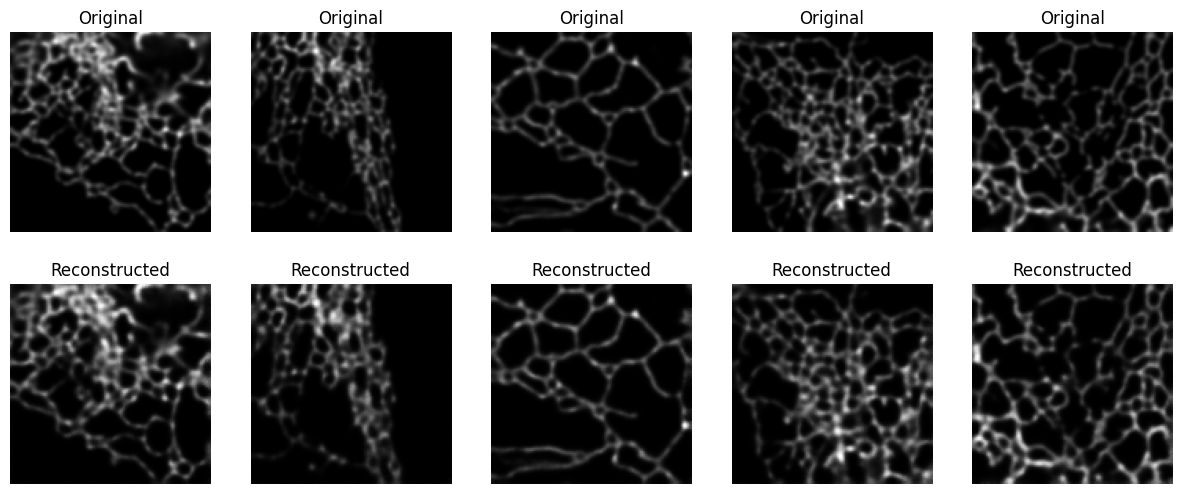

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Function to display original and reconstructed images
def visualize(images, outputs):
    num_images = len(images)
    fig, axes = plt.subplots(nrows=2, ncols=num_images, figsize=(num_images * 3, 6))

    for i in range(num_images):
        axes[0, i].imshow(np.transpose(images[i].numpy(), (1, 2, 0)).squeeze(), cmap='gray')
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        axes[1, i].imshow(np.transpose(outputs[i].detach().numpy(), (1, 2, 0)).squeeze(), cmap='gray')
        axes[1, i].set_title('Reconstructed')
        axes[1, i].axis('off')

    plt.show()

# Choose a few samples from the dataset for visualization
num_samples_to_visualize = 5
sample_dataloader = DataLoader(dataset, batch_size=num_samples_to_visualize, shuffle=True)
sample_batch, labels = next(iter(sample_dataloader))
sample_images = sample_batch[:num_samples_to_visualize]

# Assuming 'labels' is a tensor containing class labels for each sample
# Replace 'labels' with the actual tensor containing your class labels
unique_labels = torch.unique(labels)
class_indices = [torch.where(labels == label)[0] for label in unique_labels]


# Forward pass through the autoencoder
with torch.no_grad():
    reconstructed_images = autoencoder(sample_images)

# Visualize the original and reconstructed images
visualize(sample_images, reconstructed_images)


In [31]:
# Assuming 'autoencoder' is your trained model
with torch.no_grad():
    autoencoder.eval()  # Set the model to evaluation mode
    embeddings = autoencoder.encoder(sample_images)


OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.


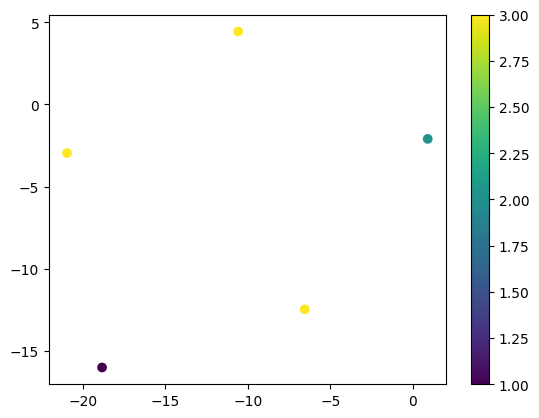

In [32]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reshape the embeddings for visualization
embeddings_reshaped = embeddings.view(embeddings.size(0), -1).numpy()

# embeddings_reshaped.shape
# labels = ['atl', 'climp', 'control', 'rtn']
# labels = [0,1,2,3]

# Apply t-SNE for dimensionality reduction and visualization
tsne = TSNE(n_components=2, perplexity=4, random_state=42)
embeddings_tsne = tsne.fit_transform(embeddings_reshaped)

# Visualize the embeddings
plt.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], c=labels, cmap='viridis')
plt.colorbar()
plt.show()


In [37]:
print(unique_labels)
print(class_indices)

tensor([1, 2, 3])
[tensor([4]), tensor([2]), tensor([0, 1, 3])]


In [48]:
# with torch.no_grad():
#     # Assuming class_indices contains indices of samples from different classes
#     class1, class2 = embeddings[class_indices[0]], embeddings[class_indices[1]]

#     # Interpolate between embeddings
#     alpha_values = torch.linspace(0, 1, steps=10)
#     interpolated_embeddings = alpha_values[:, None] * class1 + (1 - alpha_values[:, None]) * class2

#     # Decode interpolated embeddings
#     interpolated_samples = autoencoder.decoder(interpolated_embeddings)

import torch

# Assuming 'class1' and 'class2' are tensors with the same size along the third dimension
class1, class2 = embeddings[class_indices[0]], embeddings[class_indices[1]]

# print(class1.shape)
# print(class2.shape)

# alpha_values = torch.linspace(0, 1, steps=10)
# print(alpha_values)

# # Make sure both tensors have the same size along the third dimension
# min_size = min(class1.size(2), class2.size(2))
# class1 = class1[:, :, :min_size]
# class2 = class2[:, :, :min_size]

# Interpolate between embeddings
with torch.no_grad():
    alpha_values = torch.linspace(0, 1, steps=16)
    interpolated_embeddings = alpha_values[:, None] * class1 + (1 - alpha_values[:, None]) * class2

    # Decode interpolated embeddings
    interpolated_samples = autoencoder.decoder(interpolated_embeddings)



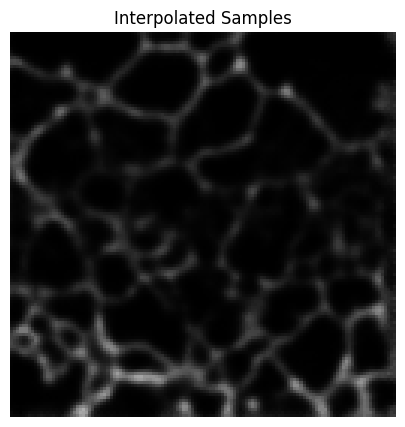

In [49]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Assuming 'interpolated_samples' is a tensor containing the generated samples
# Adjust the 'nrow' parameter based on the number of samples you want to display in each row
interpolated_grid = vutils.make_grid(interpolated_samples, nrow=len(alpha_values))

# Display the generated samples
plt.figure(figsize=(10, 5))
plt.imshow(np.transpose(interpolated_grid.numpy(), (1, 2, 0)))
plt.axis('off')
plt.title('Interpolated Samples')
plt.show()


In [51]:
sted_dataset = ImageFolder(root='/localhome/asa420/MIAL/data/sted-data/img_recon/', transform=transform)
sted_dataloader = DataLoader(sted_dataset, batch_size=5, shuffle=True)

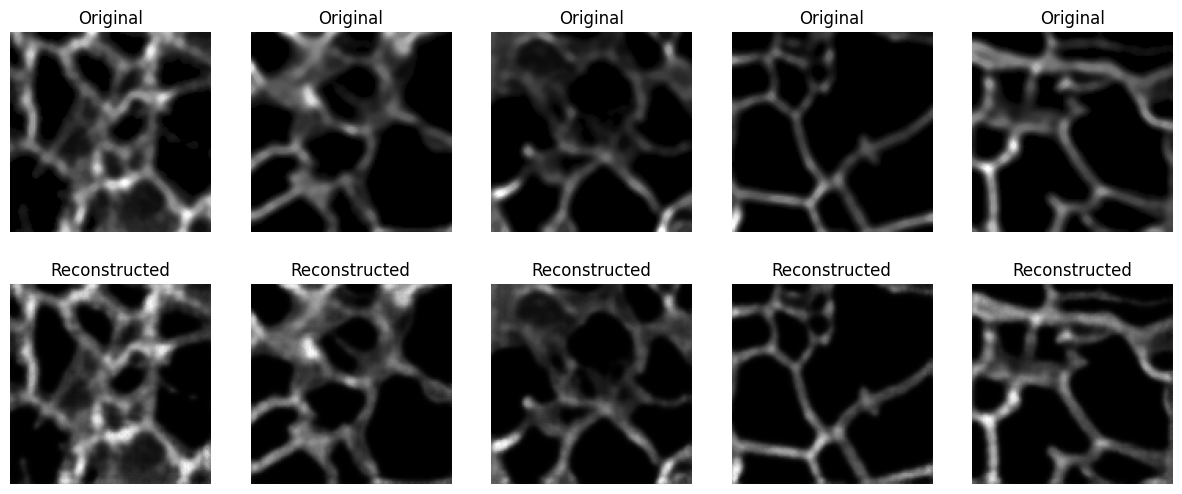

In [54]:
num_samples_to_visualize = 5
sted_batch, sted_labels = next(iter(sted_dataloader))
sample_images = sted_batch[:num_samples_to_visualize]

# Assuming 'labels' is a tensor containing class labels for each sample
# Replace 'labels' with the actual tensor containing your class labels
unique_labels = torch.unique(sted_labels)
class_indices = [torch.where(sted_labels == label)[0] for label in unique_labels]


# Forward pass through the autoencoder
with torch.no_grad():
    reconstructed_images = autoencoder(sample_images)

# Visualize the original and reconstructed images
visualize(sample_images, reconstructed_images)

In [56]:
val_dataset = ImageFolder(root='/localhome/asa420/MIAL/data/classification_data/2d_classification/val/', transform=transform)
val_dataloader = DataLoader(val_dataset, batch_size=5, shuffle=True)

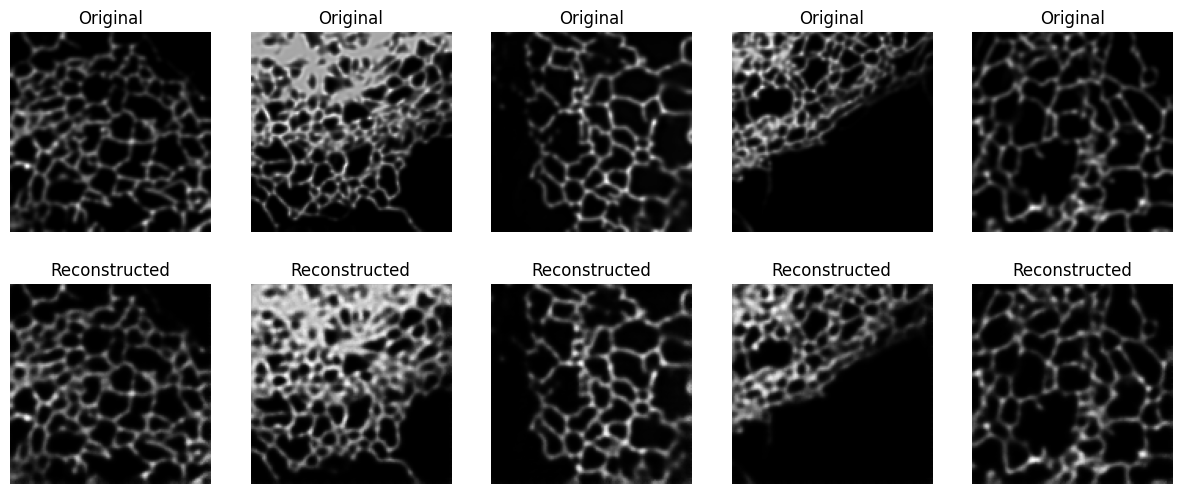

In [57]:
num_samples_to_visualize = 5
val_batch, val_labels = next(iter(val_dataloader))
sample_images = val_batch[:num_samples_to_visualize]

# Assuming 'labels' is a tensor containing class labels for each sample
# Replace 'labels' with the actual tensor containing your class labels
unique_labels = torch.unique(val_labels)
class_indices = [torch.where(val_labels == label)[0] for label in unique_labels]


# Forward pass through the autoencoder
with torch.no_grad():
    reconstructed_images = autoencoder(sample_images)

# Visualize the original and reconstructed images
visualize(sample_images, reconstructed_images)

In [61]:
l = nn.MSELoss()
print(l(sample_images[1], reconstructed_images[1]))

tensor(0.0022)


In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Define the Conditional Autoencoder model
class ConditionalAutoencoder(nn.Module):
    def __init__(self, num_classes):
        super(ConditionalAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        # Latent space
        # flattened_size = 32 * 16 * 16  # Calculate the size after flattening
        flattened_size = 5 * 32 * 32 * 32
        self.latent_space = nn.Linear(flattened_size, 256)  # Assuming the latent space has size 256

        # Conditional Decoder
        self.decoder = nn.Sequential(
            nn.Linear(256 + num_classes, flattened_size),  # Concatenate class information
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x, class_label):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)  # Flatten for the fully connected layer
        # print(x.shape)
        x = self.latent_space(x)

        # Concatenate class information to the latent space
        x = torch.cat([x, class_label], dim=1)

        x = self.decoder(x.view(x.size(0), -1, 1, 1))  # Reshape for the convolutional layers
        return x

# Hyperparameters
batch_size = 5
learning_rate = 0.001
num_epochs = 10
num_classes = 4  # Number of classes in your dataset

# Load your data (assuming you have a folder with images)
transform = transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.ToTensor()])
# dataset = ImageFolder(root='your_image_folder_path', transform=transform)
# dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

dataset = ImageFolder(root='/localhome/asa420/MIAL/data/classification_data/2d_classification/train', transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# sted_dataset = ImageFolder(root='/localhome/asa420/MIAL/data/sted-data/img_recon/', transform=transform)
# sted_dataloader = DataLoader(sted_dataset, batch_size=batch_size, shuffle=True)

# Initialize the conditional autoencoder, loss function, and optimizer
conditional_autoencoder = ConditionalAutoencoder(num_classes=num_classes)
criterion = nn.MSELoss()
optimizer = optim.Adam(conditional_autoencoder.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    for data in dataloader:
        images, labels = data

        optimizer.zero_grad()

        # One-hot encode class labels
        class_labels = torch.eye(num_classes)[labels]

        outputs = conditional_autoencoder(images, class_labels)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Save the trained model
torch.save(conditional_autoencoder.state_dict(), 'conditional_autoencoder_model.pth')


RuntimeError: mat1 and mat2 shapes cannot be multiplied (5x32768 and 163840x256)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder



# Load your data (assuming you have a folder with images)
transform = transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.ToTensor()])
dataset = ImageFolder(root='your_image_folder_path', transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize the conditional autoencoder, loss function, and optimizer
conditional_autoencoder = ConditionalAutoencoder(num_classes=num_classes)
criterion = nn.MSELoss()
optimizer = optim.Adam(conditional_autoencoder.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    for data in dataloader:
        images, labels = data

        optimizer.zero_grad()

        # One-hot encode class labels
        class_labels = torch.eye(num_classes)[labels]

        outputs = conditional_autoencoder(images, class_labels)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Save the trained model
torch.save(conditional_autoencoder.state_dict(), 'conditional_autoencoder_model.pth')
